In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv('GGXY.csv')

data = df[['Club','Ball Speed (MPH)','Launch Angle (Deg)','Face Angle (Deg)','Face to Path (Deg)', 'Carry (Yds)']]
display(data)

,Club,Ball Speed (MPH),Launch Angle (Deg),Face Angle (Deg),Face to Path (Deg),Carry (Yds)
0,54 Wedge,96.4,27.7,-5.7,-7.5,119.1
1,54 Wedge,93.7,33.4,-,-,115.1
2,54 Wedge,94.6,29.6,-4.5,-6.7,116.1
3,54 Wedge,94.3,30.6,-5.1,-8.3,121.6
4,54 Wedge,98.0,27.7,-,-,122.1
...,...,...,...,...,...,...
187,7 Iron,88.2,16.0,-2.2,-2.2,108.5
188,7 Iron,74.5,14.1,-,-,75.7
189,7 Iron,68.1,12.4,-,-,57.3
190,7 Iron,94.1,17.8,-4.3,-3.9,126.7


# **Some data points are numbers but recognized as strings, the following changes those numbers into being recognized as floats. However, some missing data are given as a -, which will remain a string**


In [4]:
data = np.array(data)
data = data[~np.any(data == '-',axis=1)]
num_rows, num_cols = data.shape

for i in range(num_rows):
    data[i,0] = int(i)
    for j in range(num_cols):
        data[i,j] = float(data[i,j])

print(data)

[[0.0 96.4 27.7 -5.7 -7.5 119.1]
 [1.0 94.6 29.6 -4.5 -6.7 116.1]
 [2.0 94.3 30.6 -5.1 -8.3 121.6]
 [3.0 92.8 30.3 0.9 -0.9 110.9]
 [4.0 96.8 26.6 -5.0 -6.4 120.7]
 [5.0 96.8 28.5 -2.4 -4.8 119.1]
 [6.0 95.8 29.0 5.1 2.5 118.8]
 [7.0 98.1 28.1 -4.7 -7.3 122.0]
 [8.0 131.0 15.4 -4.5 -4.7 198.5]
 [9.0 125.1 20.9 4.8 3.8 182.2]
 [10.0 127.7 18.2 -5.7 -2.5 195.3]
 [11.0 127.6 18.0 -2.1 -2.3 192.9]
 [12.0 127.5 18.2 -2.1 -1.1 191.8]
 [13.0 129.6 16.6 -3.9 -4.3 198.7]
 [14.0 129.9 16.4 -4.1 -3.9 196.2]
 [15.0 125.6 20.2 1.8 0.8 187.2]
 [16.0 124.1 16.7 0.8 0.6 182.7]
 [17.0 150.6 15.0 -3.0 2.2 243.0]
 [18.0 149.3 14.0 -3.7 1.1 250.2]
 [19.0 144.8 14.9 -3.4 1.2 244.6]
 [20.0 144.1 14.5 -5.3 -0.5 241.9]
 [21.0 143.4 15.3 -6.0 -1.2 242.0]
 [22.0 149.8 12.4 -4.4 -0.8 250.5]
 [23.0 150.2 13.5 -2.6 0.8 252.5]
 [24.0 143.7 14.8 -3.6 1.4 241.7]
 [25.0 150.6 12.9 -4.9 -0.9 249.8]
 [26.0 150.8 13.9 -3.2 2.6 243.1]
 [27.0 153.1 11.5 -5.0 1.4 254.7]
 [28.0 149.5 14.1 -2.3 2.5 247.9]
 [29.0 135.2 13.0 -0

In [5]:
def classify_shot(face_angle, face_to_path):
    tolerance = 5  #degrees

    # Determine the shot type
    if abs(face_angle) <= tolerance & abs(face_to_path) <= tolerance:
        return "Straight"
    
    if face_angle > tolerance:
        # Club face open 
        if face_to_path > tolerance:
            return "Slice"
        elif face_to_path < -tolerance:
            return "Fade"
        else:
            return "Push"
    
    elif face_angle < -tolerance:
        # Club face closed
        if face_to_path < -tolerance:
            return "Hook"
        elif face_to_path > tolerance:
            return "Draw"
        else:
            return "Pull"
    
    return "Uh oh"

In [6]:
def distance(ball_speed,launch_angle,g=9.8):
    angle = math.radians(launch_angle)
    speed = ball_speed * 0.488889 #correct to yards per second
    range = (speed**2) * math.sin(2*angle) / g
    return range

def check_distance(prediction, actual):
    tolerance = 0.05 * actual
    diff = prediction - actual
    if (diff < tolerance):
        return "good!"
    else:
        return diff

In [7]:
def direction(face_angle,face_to_path):
    # Weighted contributions to the ball's direction
    face_angle_weight = 0.80 
    face_path_weight = 0.20 
    curve_constant = 0.1 # changes with external conditions

    # The final direction is a combination of both
    start_direction = face_angle_weight * face_angle + face_path_weight * face_to_path
    curve = curve_constant * (face_angle-face_to_path)

    #final direction
    direction = start_direction + curve
    
    return direction #this is in degrees

def check_direction(prediction, actual):
    shot_type = classify_shot(face_angle,face_to_path)
    if shot_type == ("Slice" | "Fade" | "Push"):
        assert prediction > 0, "angle for right-side shot should be positive"
    elif shot_type == ("Hook" | "Draw" | "Pull"):
        assert prediction < 0, "angle for less-side shot should be negative"

    tolerance = .05 * actual
    diff = prediction - actual
    if (diff < tolerance):
        return "good!"
    else:
        return diff

In [8]:
def final(distance, degrees):
    carry = distance / math.cos(math.radians(degrees))
    
    return carry #yards


# **Here's an example of a driver shot by Tiger Woods**

In [9]:
# Example: a driver shot by Tiger Woods
ex_faceangle = 0
ex_face2path = 2 #assume a little fade
ex_ballspeed = 180 #mph
ex_launchangle = 12 #degrees

ex_distance = distance(ex_ballspeed,ex_launchangle)
ex_direction = direction(ex_faceangle,ex_face2path)

ex_final = final(ex_distance,ex_direction)
print(f'Predicted carry: {ex_final:.2f} yards, {ex_direction} degrees away from center')

Predicted carry: 321.41 yards, 0.2 degrees away from center


(-5.0, 350.0)

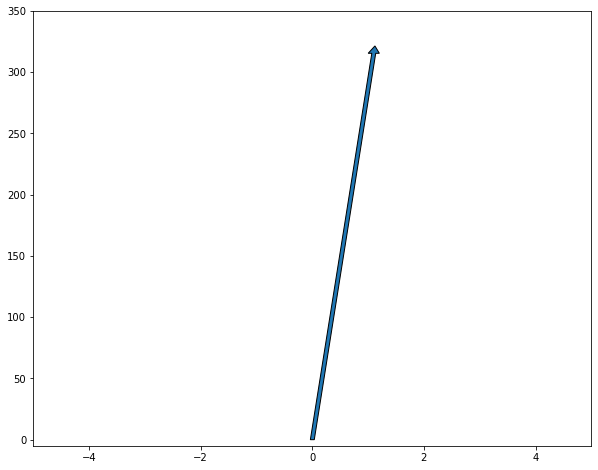

In [10]:
direction_yards = math.sqrt(ex_final**2 - ex_distance**2)

plt.figure(figsize=(10,8))
plt.arrow(0,0, direction_yards, ex_distance, width = 0.07, head_width=0.2, head_length = 6, length_includes_head = True)
plt.xlim(-5,5)
plt.ylim(-5,350)

# **Prediction on all the data**

In [11]:
def predict(data,index):
    ball_speed, launch_angle, face_angle, face_to_path = data[index,1:5]
    true_carry = data[index,5]

    dist = distance(ball_speed,launch_angle)
    degrees = direction(face_angle,face_to_path)

    carry = final(dist,degrees)
    direction_yards = math.sqrt(carry**2 - dist**2)
    
    #print(f'Predicted carry: {carry:.2f} yards, {degrees:.2f} degrees ({direction_yards:.2f} yards) away from center')
    
    deviation = carry-true_carry
    #print(f'Carry deviation: {deviation:.2f} yards \n')
    
    return deviation

In [12]:
devs = []
percent_devs = []
for i in range(num_rows):
    deviation = predict(data,i)
    devs.append(deviation)
    percent_dev = devs[i] / data[i,5] * 100
    percent_devs.append(percent_dev)

# **PCA**

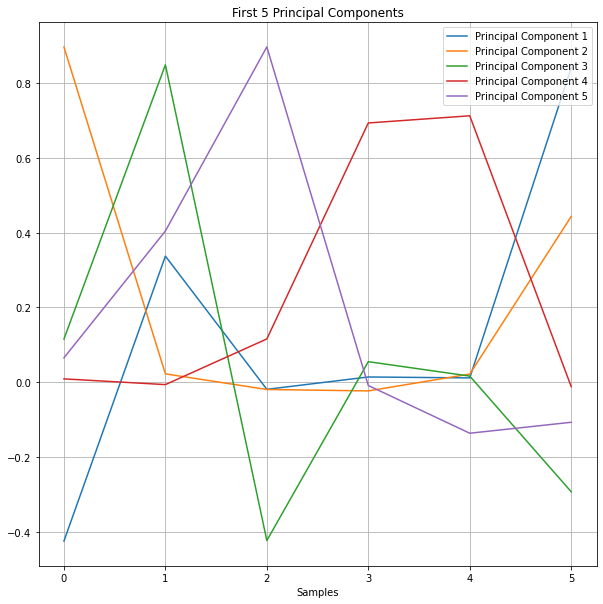

In [14]:
from sklearn.decomposition import PCA 
data_ctd = data - np.mean(data, axis=0)

pca = PCA()
pca.fit(data_ctd)

cov_mat = pca.get_covariance()

evals = (pca.singular_values_ ** 2) / (data_ctd.shape[0] - 1)

evecs = pca.components_.T

plt.figure(figsize=(10,10))
for i in range(5):
    legend = f'Principal Component {i+1}'
    plt.plot(evecs[:, i], label=legend)

plt.title('First 5 Principal Components')
plt.xlabel('Samples')
plt.legend()
plt.grid(True) 
plt.show()

# **Linear Regression**